In [5]:
from pathlib import Path

from astropy.io import fits
from astropy.io.fits.fitsrec import FITS_rec
from numpy.typing import NDArray
import numpy as np
from scipy.interpolate import griddata

import darksun as ds

ds.show.set_figures_darkbkg()

## **Energy Bands Absrp Dist Extraction - Analytic Approach**

In [ ]:
def load_fits_data(path: Path, ext: int = 1) -> FITS_rec:
    """Loads the FITS file data from chosen extension."""
    return fits.getdata(path, ext=ext, header=False)

def extract_transmission(
    data: FITS_rec,
    energy_range: tuple[float, float] = (2.0, 50.0),
) -> tuple[NDArray, NDArray]:
    """
    Extracts photons transmission values in specified `energy_range`.
    """
    energy: NDArray = data.field(0)
    transmission: NDArray = data.field(1)
    low, high = energy_range
    band: NDArray = (energy >= low) & (energy <= high)
    return energy[band], transmission[band]

def interp(
    x: NDArray,
    y: NDArray,
    energy: NDArray,
) -> NDArray:
    """Interpolates `y` values in given `energy` values."""
    # ...
    # some preprocess (?)
    # ...
    return griddata(x, y, energy, method='linear')

def integrate(arr: NDArray, bins: NDArray) -> float:
    """Integrates input array."""
    return np.sum(arr * bins)

In [7]:
def _transform(theta_x: float, theta_y: float) -> float:
    """
    Computes transformation between local-frame and polar
    frame. Input angles are in [deg]. The output is the
    tangent of the polar angle wrt the XY plane.
    """
    tan_x, tan_y = map(
        lambda x: np.tan(np.deg2rad(x)), (theta_x, theta_y),
    )
    return np.sqrt(tan_x ** 2 + tan_y ** 2)

def compute_theta(theta_x: float, theta_y: float) -> float:
    """
    Computes the polar angular coord wrt to the xy plane.
    Both `theta_x` and `theta_y` are in [deg].
    Output angle value is in [deg].
    """
    xi: float = _transform(theta_x, theta_y)
    return np.rad2deg(np.atan(xi))

def project_absrp_correction(
    distance: float,
    theta_x: float,
    theta_y: float,
) -> NDArray:
    """
    Computes the source local-frame coords correction for the
    detector absorption photons distance in a given energy band.
    """
    xi: float = _transform(theta_x, theta_y)
    theta_plane_proj: float = np.sin(np.atan(xi))
    local_angles: NDArray = np.deg2rad(np.array([theta_x, theta_y]))
    phi_local_proj: NDArray = np.tan(local_angles) / (xi + 1e-8)
    return distance * theta_plane_proj * phi_local_proj

- We want to compute the median absorption distance on the detector for an incident photon with energy $E$, for the SDDs inside each LEM-X camera.

- The travel distance $x$ for a photon with energy $E$ is linked to the detector material transmission (Si-based):

$$ T(x, E) \propto \text{exp}[- \rho\mu(E) \cdot x] $$

- The median distance is then:

$$ \hat{\text{x}}(E) = \frac{\text{ln}(2)}{\rho\mu(E)} $$

In [8]:
#settings_path: str = "/mnt/dbb8f47e-da06-47bf-8ef5-038092af70f7/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data/Simulations/camera_settings"
settings_path: str = "/mnt/d/PhD_AASS/Coding/Images_fits/camera_settings"

detSi_matten: FITS_rec = load_fits_data(Path(settings_path, "detectorSi_absrp.fits"))

In [9]:
# extract detector density, thickness and mass attenuation (ON-AXIS)
rho: float = 2.33   # [g/cm3] (from FITS header)
d: float = 0.045    # [cm]
energy, matten = extract_transmission(detSi_matten)  # [keV], [cm2/g]

In [10]:
def compute_median_dist(ph_energy: float) -> float:
    """
    Computes detector median absorption distance
    in [cm] for a photon with `ph_energy` keV.
    """
    mu = interp(energy, matten, ph_energy)
    return np.log(2) / (rho * mu)


ph_energy = 20.0                # [keV]
theta_x, theta_y = 30.0, 30.0

# LoS mean absrp distance in the detector [mm]
dist: float = 10 * compute_median_dist(ph_energy)

_theta = np.deg2rad(compute_theta(theta_x, theta_y))
depth = dist * np.cos(_theta)
print(
    f'Photon mean distance absorption: {dist:.4f} mm\n'
    f'Detector penetration: {depth:.4f} mm (detected: {depth < 10 * d})\n'
    f'Impact deviation: {dist * np.sin(_theta):.4f} mm\n'
)

dsx, dsy = project_absrp_correction(dist, theta_x, theta_y)
print(f'Local-frame coords correction (x, y): {dsx:.4f}, {dsy:.4f} mm')

Photon mean distance absorption: 0.7275 mm
Detector penetration: 0.5636 mm (detected: False)
Impact deviation: 0.4601 mm

Local-frame coords correction (x, y): 0.3254, 0.3254 mm


- If we want to know the median distance in a given energy interval $[E_{1}, E_{2}]$, we have to integrate.

In [11]:
theta_x, theta_y = 15.0, 15.0                      # [deg]
energy_range: tuple[float, float] = (8.0, 14.0)  # [keV]

energy_, matten_ = extract_transmission(detSi_matten, energy_range)  # [keV], [cm2/g]
dist: float = 10 * (np.log(2) / rho) * integrate(1.0 / matten_[:-1], np.diff(energy_)) # [mm]

_theta = np.deg2rad(compute_theta(theta_x, theta_y))
depth = dist * np.cos(_theta)
print(
    f'Photon mean distance absorption: {dist:.4f} mm\n'
    f'Detector penetration: {depth:.4f} mm (detected: {depth < 10 * d})\n'
    f'Impact deviation: {dist * np.sin(_theta):.4f} mm\n'
)

dsx, dsy = project_absrp_correction(dist, theta_x, theta_y)
print(f'Local-frame coords correction (x, y): {dsx:.4f}, {dsy:.4f} mm')

Photon mean distance absorption: 0.7568 mm
Detector penetration: 0.7077 mm (detected: False)
Impact deviation: 0.2682 mm

Local-frame coords correction (x, y): 0.1896, 0.1896 mm


<br>

## **Energy Bands Absrp Dist Extraction - SemiAnalytic Approach**

- Let's try a semi-analytic approach: from the transmission PDF $T(E, x)$ we can compute the distr of the positions at a given energy value.<br>
The median absorption distance will be extracted by computing $T(E, x)\space |\space \{x < d\}$ with $d$ the thickness of the SDD.

- To accomodate the computations, the SDD transmission is wrote as:

$$ T(\xi, E) = \alpha (E) \cdot \text{exp} \left[-\alpha (E) \xi\right] $$

where $ \alpha (E) = \rho\mu(E)d $ and $ \xi = x / d $, so that $ \xi \in [0, 1] $ automathically setting the transmission inside the SDD.

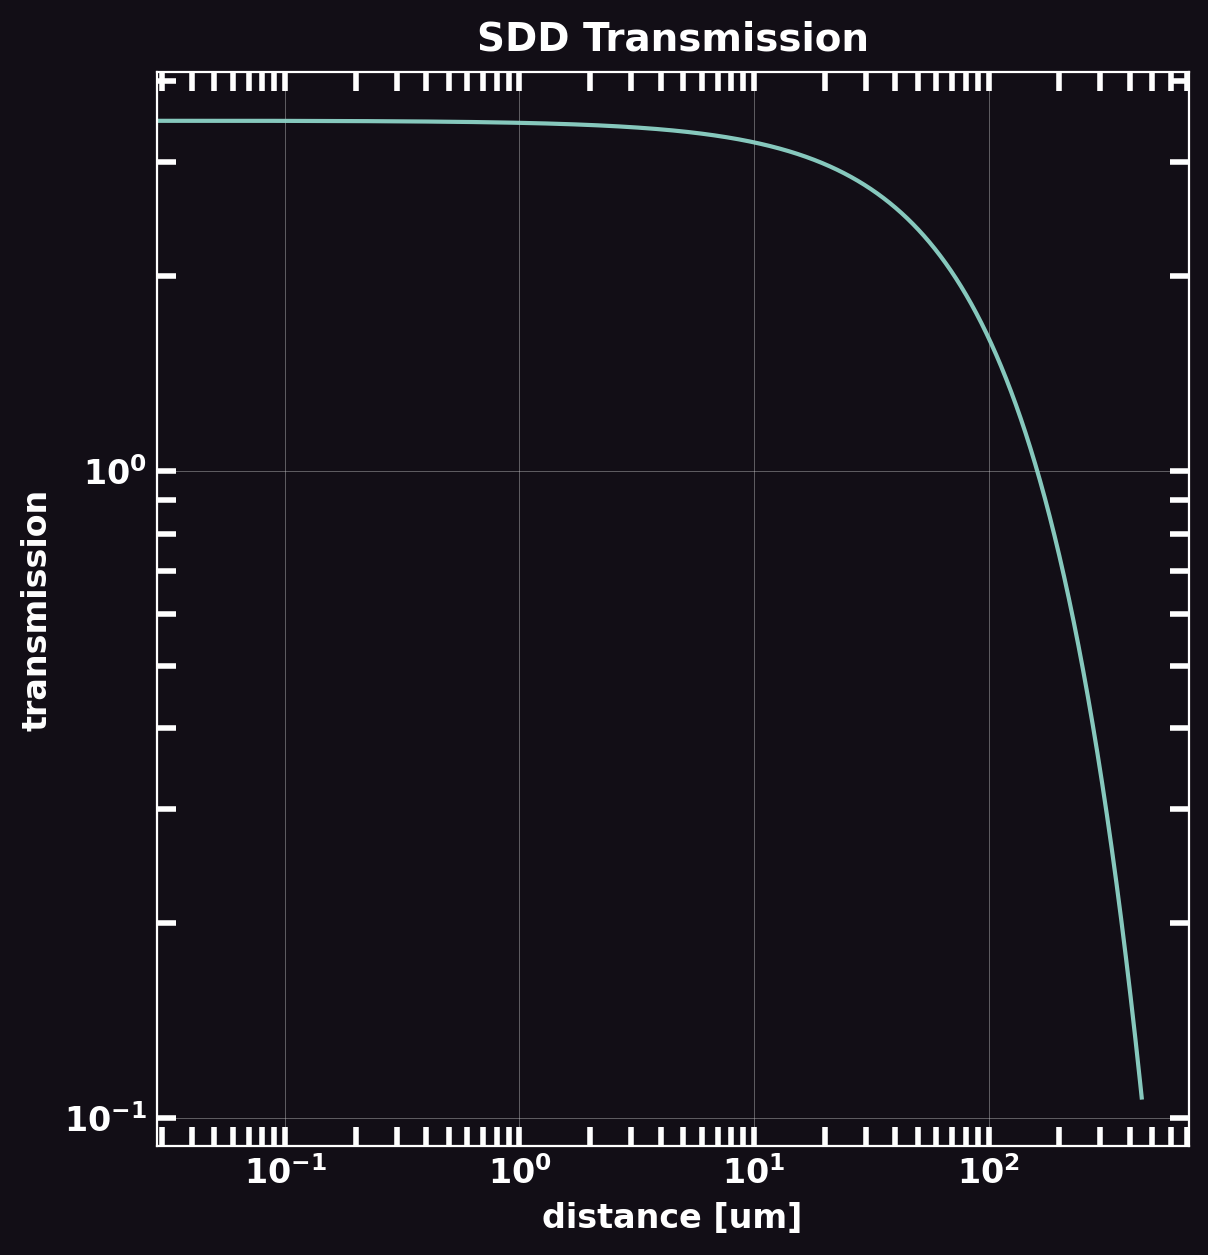

(np.float64(0.0017903912478804), np.float64(0.002582988574568056))

In [33]:
SDD_PARAMS = {
    'rho': 2.33e-3,   # [g/mm3] (from FITS header),
    'd': 0.45,        # [mm]
}

def compute_SDD_transmission(
    unit_dist: NDArray,
    ph_energy: float,
) -> NDArray:
    """Computes a photon transmission with given energy inside the SDD."""
    mu = 1e2 * interp(energy, matten, ph_energy)  # [mm2/g]
    alpha = SDD_PARAMS['rho'] * mu * SDD_PARAMS['d']
    return alpha * np.exp(-alpha * unit_dist)

def comp_median(
    unit_dist: NDArray,
    ph_energy: float,
) -> float:
    """Computes the median absorption distance of a photon inside the SDD."""
    meas_set = unit_dist * compute_SDD_transmission(unit_dist, ph_energy)
    #return SDD_PARAMS['d'] * np.sort(meas_set)[(len(unit_dist) - 1) // 2]
    return SDD_PARAMS['d'] * np.log(2) * integrate(meas_set[:-1], np.diff(meas_set))

def comp_mean(
    unit_dist: NDArray,
    ph_energy: float,
) -> float:
    """Computes the mean absorption distance of a photon inside the SDD."""
    meas_set = unit_dist * compute_SDD_transmission(unit_dist, ph_energy)
    #return SDD_PARAMS['d'] * np.mean(meas_set)
    return SDD_PARAMS['d'] * integrate(meas_set[:-1], np.diff(meas_set))


ph_energy = 10.0  # [keV]
unit_dist: NDArray = np.log(np.logspace(0, 1, int(1e4 + 1), base=np.e))

ds.plot(
    ds.map4plot(
        arrs=compute_SDD_transmission(unit_dist, ph_energy),
        title='SDD Transmission',
        x=1e3 * SDD_PARAMS['d'] * unit_dist,
        xlabel='distance [um]',
        ylabel='transmission',
        yscale='log',
        xscale='log',
    ),
)

comp_median(unit_dist, ph_energy), comp_mean(unit_dist, ph_energy)

- Neither this way seems to be efficient, since the photons at energies higher than $\sim 17$ keV are absorbed outside the SDD thickness.

- This approach shows the same problems as in the analytical approach.

<br>

<br>

## **IROS Benchmark Test - Energy Bands Absrp Dist Extraction**

- In this approach, we'll compute the **median absorption distance** of the photons in a given energy band $\Delta E$ directly from the WISEMAN originated events.

- In the "IROS benchmark" test, a mock sky-field with Crab-like sources is simulated. The sources are uniformly distribuited in the camera FoV, and have the same emission spectrum (from the Crab pulsar, i.e. with breaking index $ n = 2.1 $, typical of a stable neutron star with energy loss dominated by EM emission).

- In the `demo_source_obs_spectrum.ipynb` file it is established that Crab-like sources have $ \sim $ stable photons emission percentage wrt total emission counts in given energy bands and at different sky coords. To fit well enough a source during the sky-field IROS reconstruction, we can decompose the the full band ([2, 50] keV) source shadowgram into $\Delta\textit{E}$ related components, weighted by the counts percentage in that energy band wrt the measured total counts.

- Since photons with higher energies are absorbed deeper in the camera SDD, the shadowgram components have energy dependent coordinates. By measuring the median absrp distance in the chosen energy bands from the WM events, we can estimate a correction $\delta\textit{s}$ to apply to the source coords in the camera local-frame. The correction depends on the photons energy and on the source coords.

- By analysing the median absrp distance $\hat{\xi}$ of the photons in a given energy band $\Delta\textit{E}$ wrt the source coords in the camera local-frame, maybe it'll be possible to extrapolate a law to compute the correction $\delta\textit{s}$.

In [ ]:
from singleCAM_IROS._pipeline_support import _handle_dirpaths

from pathlib import Path
import numpy as np
from numpy.typing import NDArray
from astropy.io.fits.fitsrec import FITS_rec

from bloodmoon.coords import equatorial2shift, shift2angle
from bloodmoon.types import CoordEquatorial
from bloodmoon.io import simulation_files
from bloodmoon.mask import CodedMaskCamera
from bloodmoon.mask import codedmask

import darksun as ds
from darksun.data import DataLoader, CatalogueLoader
from darksun.benchmarking import source_catalogue_data

ds.show.set_figures_darkbkg()

In [22]:
from typing import NamedTuple

class CoordAngular(NamedTuple):
    """Angular source coords in camera local-frame."""
    theta_x: float
    theta_y: float

type EnergyRange = tuple[float, float]

def equatorial2angle(
    coords: CoordEquatorial,
    camera: CodedMaskCamera,
    sdl: DataLoader,
) -> CoordAngular:
    """
    Converts source RA/Dec coords in camera local-frame angular
    coords along (fine, coarse) directions, in [deg].
    """
    shifts = equatorial2shift(sdl, camera, coords.ra, coords.dec)
    tx, ty = map(lambda x: shift2angle(camera, x), shifts)
    return CoordAngular(tx, ty)

def _transform(theta_x: float, theta_y: float) -> float:
    """
    Computes transformation between local-frame and polar
    frame. Input angles are in [deg]. The output is the
    tangent of the polar angle wrt the XY plane.
    """
    tan_x, tan_y = map(
        lambda x: np.tan(np.deg2rad(x)), (theta_x, theta_y),
    )
    return np.sqrt(tan_x ** 2 + tan_y ** 2)

def compute_theta(theta_x: float, theta_y: float) -> float:
    """
    Computes the polar angular coord wrt to the xy plane.
    Both `theta_x` and `theta_y` are in [deg].
    Output angle value is in [deg].
    """
    xi: float = _transform(theta_x, theta_y)
    return np.rad2deg(np.atan(xi))

def comp_coords_correction(
    depth: float,
    coords: CoordAngular,
) -> NDArray:
    """
    Computes the source local-frame coords correction based on the
    chosen value of the photons absorption depth in the SDD from
    a specified direction, in the analysed energy band.
    """
    xi: float = _transform(*coords)
    theta_plane_proj: float = np.tan(np.atan(xi))
    local_angles: NDArray = np.deg2rad(np.array(coords))
    phi_local_proj: NDArray = np.tan(local_angles) / (xi + 1e-8)
    return depth * theta_plane_proj * phi_local_proj

**Mask and Data Specifics**

In [4]:
MASK_FITS: str = "wfm_mask_NTHT_20250725.fits"

SKYFIELD: str = "IROSDummy"
DATA_FITS: str = "iros_benchmark_2-50keV_mask_050_1040x17_1ks"

ID_CAMERA_A: str = "cam1a"
ID_CAMERA_B: str = "cam1b"
DATASET: str = "reconstructed"

UPS_X: int = 5
UPS_Y: int = 1

#VIGNETTING: bool = True
#PSFY: bool = True

**Load Mask and Data**

In [5]:
# load filepaths
mask_path, simul_data, save_path = _handle_dirpaths(
    mask=MASK_FITS,
    skyfield=SKYFIELD,
    simul=DATA_FITS,
)
wfm: CodedMaskCamera = codedmask(mask_path, UPS_X, UPS_Y)
filepaths: dict[str, dict[str, Path]] = simulation_files(simul_data)

# data from camera A
sdlA = ds.get_data(filepaths[ID_CAMERA_A][DATASET])
catalogueA = ds.get_catalogue(filepaths[ID_CAMERA_A]['sources'])

# data from camera B
sdlB = ds.get_data(filepaths[ID_CAMERA_B][DATASET])
catalogueB = ds.get_catalogue(filepaths[ID_CAMERA_B]['sources'])

In [63]:
def get_source_coords(
    sourceID: str,
    catalogue: CatalogueLoader,
) -> CoordEquatorial:
    """Retrieves the source RA/Dec coords from catalogue."""
    data = source_catalogue_data(sourceID, catalogue.DLdata)
    return CoordEquatorial(data['RA'], data['DEC'])

def extract_photons(
    sdl: DataLoader,
    coords: CoordEquatorial,
) -> FITS_rec:
    """Extracts photons from input direction."""
    return ds.select_source_photons(coords, sdl.DLdata, False)

def filter_energy(
    photons: FITS_rec,
    E_min: float | None,
    E_max: float | None,
) -> FITS_rec:
    """Filters the input photons by energy, in [keV]."""
    return ds.filter_data(photons, E_min=E_min, E_max=E_max, coords=None)


# -------------------------------------------------------------------------------------------------
# - In the IROS_benchmark WM simulation, all the sources have a Crab spectrum, i.e. with `n = 2.1`.
# - From `demo_source_obs_spectrum.ipynb`, it is established that a source with `n = 2.1` has the
#   following photon counts percentage (computed by using 100 sources):
#       * (2.0, 5.0) keV    |  median: 48.342%,   mean: 48.077%,   std: 2.223 perc points
#       * (5.0, 7.0) keV    |  median: 19.620%,   mean: 19.668%,   std: 0.431 perc points
#       * (7.0, 10.0) keV   |  median: 15.392%,   mean: 15.453%,   std: 0.510 perc points
#       * (10.0, 20.0) keV  |  median: 14.081%,   mean: 14.198%,   std: 1.011 perc points
#       * (20.0, 50.0) keV  |  median:  1.773%,   mean:  1.809%,   std: 0.238 perc points
# -------------------------------------------------------------------------------------------------
sourceID: str = 's17'
eband: EnergyRange = (20.0, 50.0)

coords: CoordEquatorial = get_source_coords(sourceID, catalogueA)    # equatorial coords [deg]
localcoords: CoordAngular = equatorial2angle(coords, wfm, sdlA)      # local-frame angular coords [deg]
phs: FITS_rec = extract_photons(sdlA, coords)

eband_phs: FITS_rec = filter_energy(phs, *eband)

print(
    f'Photons counts in {eband} keV: {len(eband_phs)} ph'
)

Photons counts in (20.0, 50.0) keV: 17702 ph


In [64]:
def set_zphotons_mask(zphotons: NDArray, val: float) -> NDArray:
    """Configures 'ZPHOTON' array mask for artefacts removal."""
    return (zphotons > -abs(val)) & (zphotons < abs(val))

def compute_phs_absrpdepth(data: FITS_rec) -> NDArray:
    """
    Computes the absorption depth distance in the SDD
    of the detected photons.
    """
    med_detcr_depth: float = 0.225  # [mm]
    zphotons: NDArray = data['ZPHOTON']
    vals: NDArray = set_zphotons_mask(zphotons, med_detcr_depth)
    return np.abs(zphotons[vals] - med_detcr_depth)


depth_arr: NDArray = compute_phs_absrpdepth(eband_phs)  # [mm]

m: NDArray = set_zphotons_mask(eband_phs['ZPHOTON'], 0.225)
ph_energies: NDArray = eband_phs['ENERGY'][m]                 # filtered phs energy [keV]

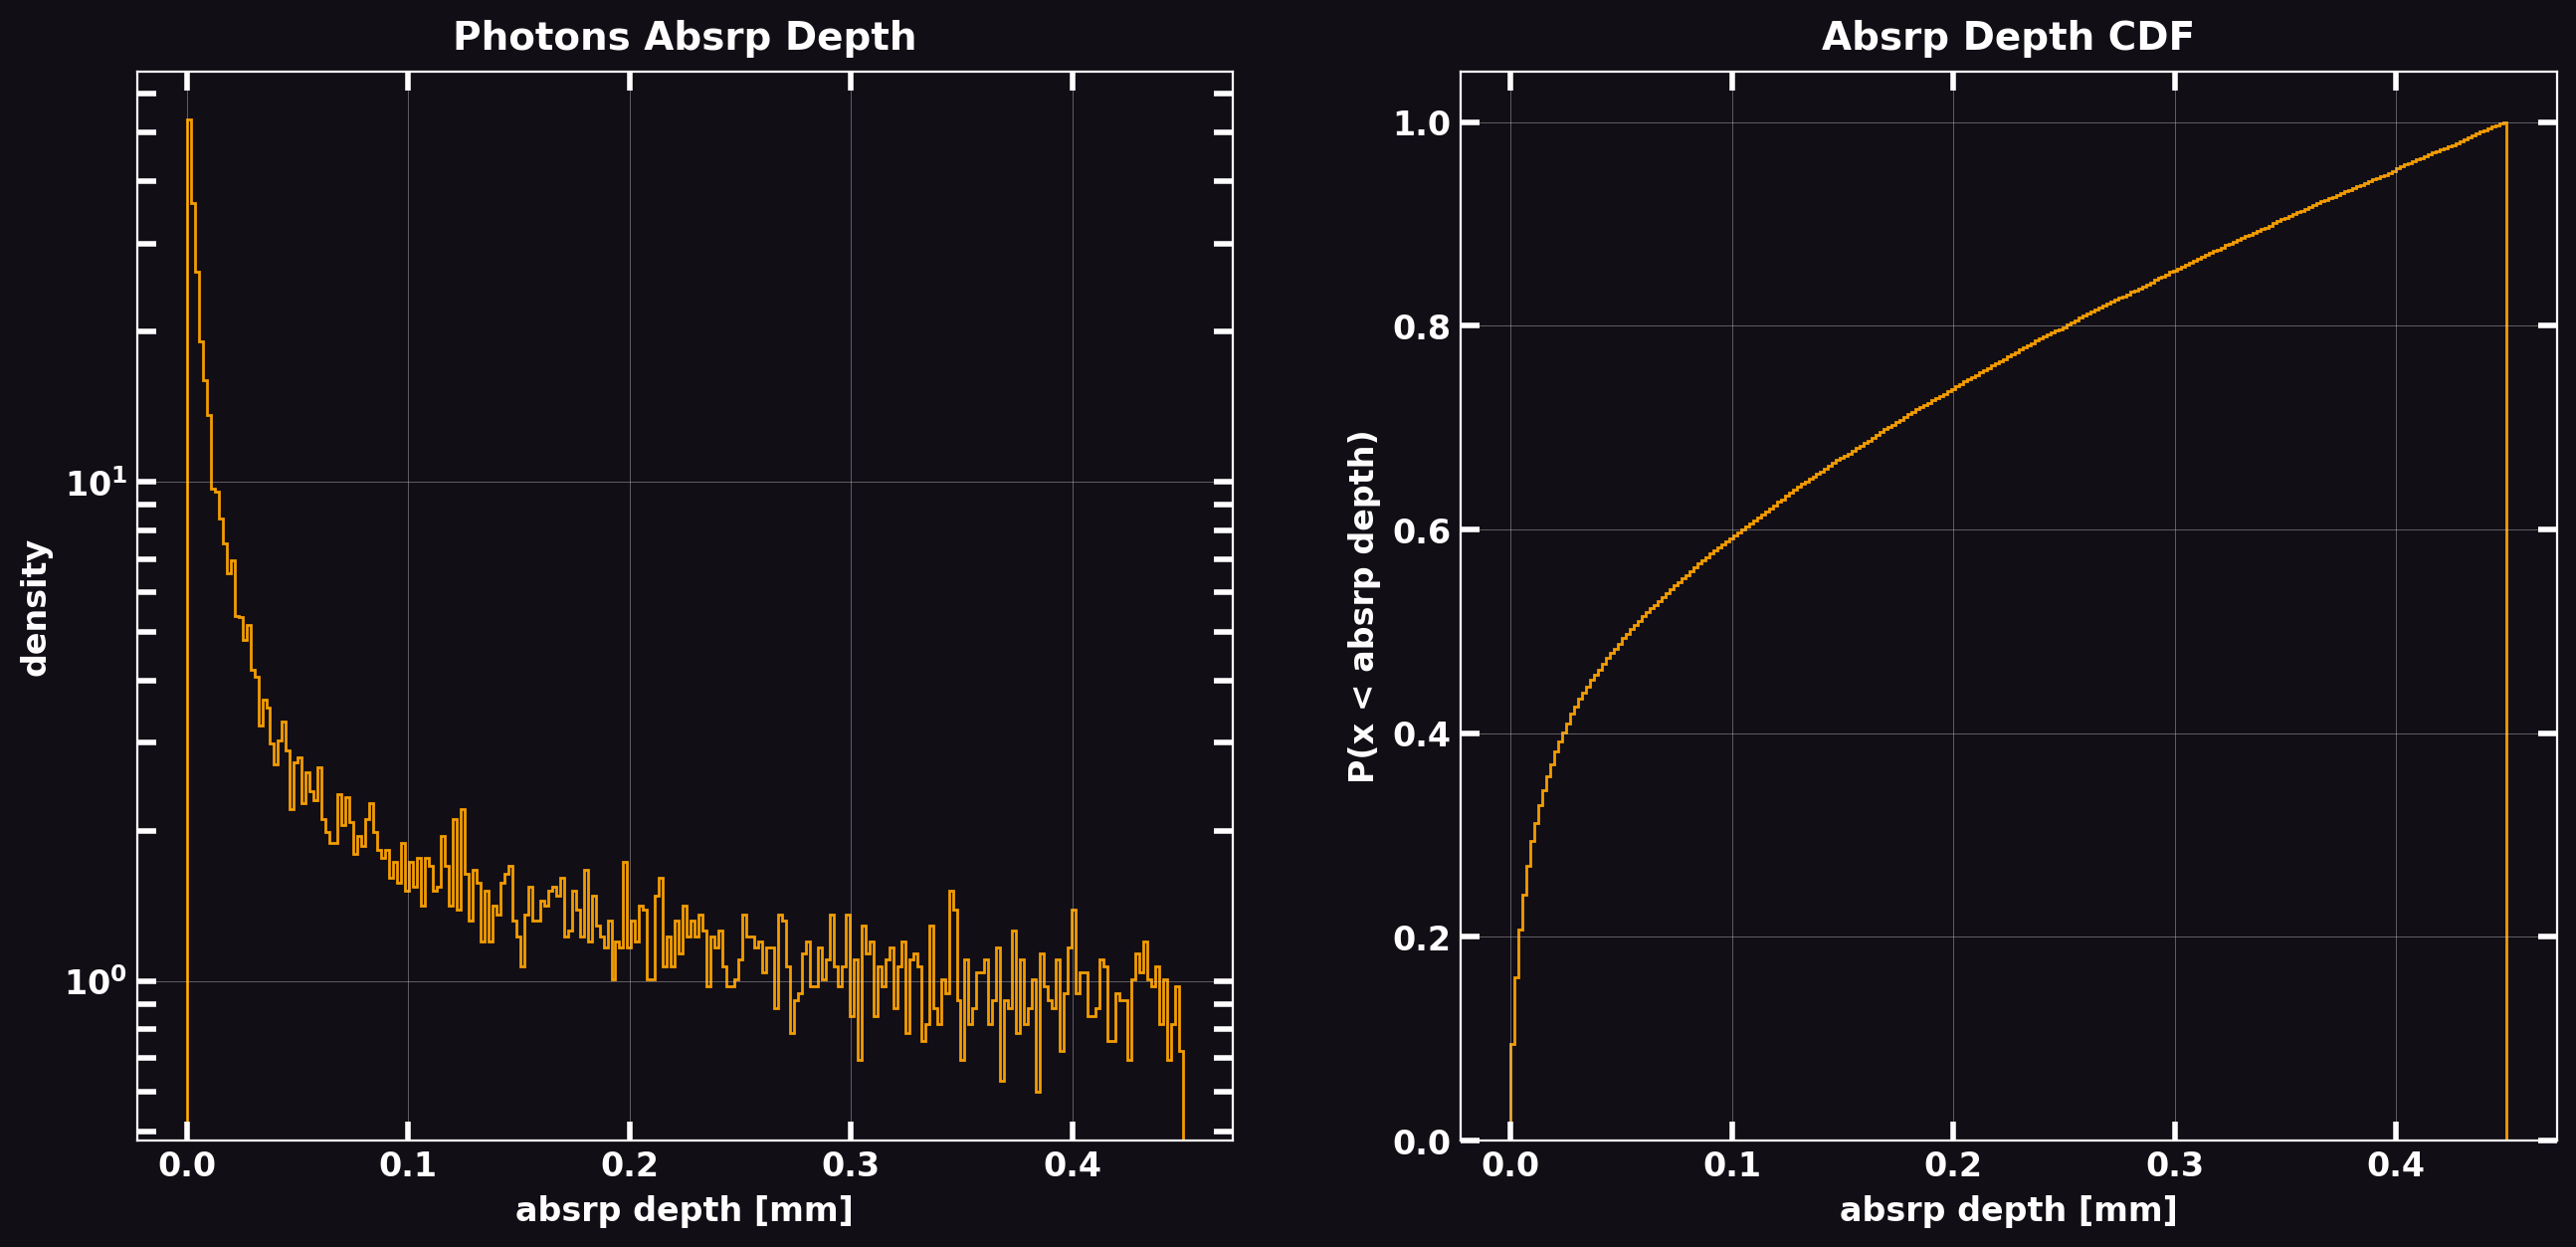

In [65]:
def compute_cdf(distr: NDArray, bins: NDArray) -> NDArray:
    """Computes the CDF of the input normalised distribution."""
    return np.cumsum(distr * np.diff(bins))


depth_hist, bins = np.histogram(depth_arr, bins=251, density=True)  # [mm]
depth_cdf = compute_cdf(depth_hist, bins)

ds.plot(
    dmaps=(
        ds.map4plot(
            arrs=depth_hist,
            title='Photons Absrp Depth',
            x=bins,
            xlabel='absrp depth [mm]', #'absrp depth [$\\mu$m]',
            ylabel='density',
            style='stairs',
            yscale='log',
            color='Orange',
        ),
        ds.map4plot(
            arrs=depth_cdf,
            title='Absrp Depth CDF',
            x=bins,
            xlabel='absrp depth [mm]', #'absrp depth [$\\mu$m]',
            ylabel='P(x < absrp depth)',
            style='stairs',
            color='Orange',
        ),
    ),
    ncols=2,
)

In [ ]:
def extract_dist_from_cdf(cdf: NDArray, bins: NDArray, value: float) -> float:
    """Extracts bins value at which an amount of `value`% data is observed."""
    idx: int = np.argwhere((cdf < value))[-1][0]
    return bins[idx]

def verbose(depth: float, coords: CoordAngular) -> None:
    """Prints out info on photons absorption."""
    # compute angle in polar coords
    tx_, ty_ = coords
    polar_angle: float = np.deg2rad(compute_theta(tx_, ty_))  # [rad]
    # print info
    print(
        f'Photon absorption in {eband} keV from ({tx_:.2f}, {ty_:.2f}) deg\n'
        f'  - Detector penetration: {depth:.4f} mm\n'
        f'  - Impact deviation: {depth * np.tan(polar_angle):.4f} mm\n'
    )
    pxs_dim = (
        wfm.specs.mask_deltax / wfm.upscale_f.x,
        wfm.specs.mask_deltay / wfm.upscale_f.y,
    )
    dsx, dsy = comp_coords_correction(depth, coords)
    print(
        f'Pixels spatial resolution (x, y): {pxs_dim[0]:.4f}, {pxs_dim[1]:.4f} mm\n'
        f'Local-frame coords correction (x, y): {dsx:.4f}, {dsy:.4f} mm\n'
    )

# - depth value for which we observe `value`% of the ph counts in the distribution
# - NOTE: we should choose the sigma values to compute the depth distance
#     * in (2.0, 5.0) keV we have ~50% of the total counts and high statistic, and I think 68% is OK;
#     * in (20.0, 50.0) keV we have low statistic (~2% of total cts), so at least 90%.
depth_dist: float = extract_dist_from_cdf(depth_cdf, bins, 0.68)
print('\n## With absrp depth from CDF:'.upper())
verbose(depth_dist, localcoords)

# distr mean depth value
mean_depth_dist: float = np.sum(bins[:-1] * depth_hist * np.diff(bins)) / np.sum(depth_hist * np.diff(bins))
print('\n## With mean absrp depth:'.upper())
verbose(mean_depth_dist, localcoords)


## WITH ABSRP DEPTH FROM CDF:
Photon absorption in (20.0, 50.0) keV from (-28.10, 17.15) deg
  - Detector penetration: 0.1560 mm
  - Impact deviation: 0.0962 mm

Pixels spatial resolution (x, y): 0.0500, 0.5000 mm
Local-frame coords correction (x, y): -0.0833, 0.0481 mm


## WITH MEAN ABSRP DEPTH:
Photon absorption in (20.0, 50.0) keV from (-28.10, 17.15) deg
  - Detector penetration: 0.1179 mm
  - Impact deviation: 0.0727 mm

Pixels spatial resolution (x, y): 0.0500, 0.5000 mm
Local-frame coords correction (x, y): -0.0630, 0.0364 mm

